In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/포트폴리오 자료/healthcare_noshows(원본).csv')

문제: 병원 예약 후 환자가 방문하지 않는 문제 (No-show)

목표: 환자가 예약을 지킬지(No-show 여부)를 예측하여 해결


Reducing Medical Appointment No-Shows
Using Machine Learning and Patient Behavior Analysis

##1. 전처리

In [4]:
df.head()

#칼럼별 전처리 계획
# PatientId, AppointmentID -> 삭제
# ScheduledDay, AppointmentDay -> 파생변수로 변경 (scheduled_weekday, appointment_weekday)
# Date.diff -> 음수 제거
# 질병 (Hipertension	Diabetes	Alcoholism) -> 하나로 합산, 이후 기존 칼럼은 제거
# 지역은 지역별 노쇼 비율 구하여 새로운 칼럼 생성
# 성별, 나이, 지원 여부, 장애 여부, SMS 수신 여부는 수정 X
# No-show 여부는 Showed_up에서 No_show 기준으로 수정
# bool형 변수는 전부 int형(0/1)으로 수정

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Showed_up,Date.diff
0,2.987250e+13,5642903,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,True,0
1,5.589978e+14,5642503,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,True,0
2,4.262962e+12,5642549,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,True,0
3,8.679512e+11,5642828,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,True,0
4,8.841186e+12,5642494,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,True,0


In [5]:
#보기 편하게 showed_up칼럼을 No_show로 변경

# No-show 컬럼 생성
df["No_show"] = ~df["Showed_up"]

df = df.drop(columns=['Showed_up'])

In [6]:
# ID 컬럼 삭제 >> 환자 개개인을 분류하려는 식별자일 뿐 분석할 정보가 없는 데이터
# 단순 식별자, 패턴 없음, 모델 생성에 기여하지 않고 학습에 문제가 될 수 있음
df = df.drop(columns=['PatientId', 'AppointmentID'])

# 확인
df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show
0,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,0,False
1,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,0,False
2,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,0,False
3,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,False
4,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,0,False


In [7]:
# 날짜형으로 변환 >> 원본 날짜의 경우 모델 입력에 적절하지 않음 -> 파생 변수로 변경
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# 확인
df.dtypes

,0
Gender,object
ScheduledDay,datetime64[ns]
AppointmentDay,datetime64[ns]
Age,int64
Neighbourhood,object
Scholarship,bool
Hipertension,bool
Diabetes,bool
Alcoholism,bool
Handcap,bool


In [8]:
# 예약 요일 >> 파생 변수를 통해 환자 예약 행동 패턴을 설명하는 변수로 활용될 수 있음
# Monday = 0
df['scheduled_weekday'] = df['ScheduledDay'].dt.weekday

# 진료 요일
df['appointment_weekday'] = df['AppointmentDay'].dt.weekday

df.head()

,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday
0,F,2016-04-29,2016-04-29,62,JARDIM DA PENHA,False,True,False,False,False,False,0,False,4,4
1,M,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,False,False,False,False,False,0,False,4,4
2,F,2016-04-29,2016-04-29,62,MATA DA PRAIA,False,False,False,False,False,False,0,False,4,4
3,F,2016-04-29,2016-04-29,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,False,4,4
4,F,2016-04-29,2016-04-29,56,JARDIM DA PENHA,False,True,True,False,False,False,0,False,4,4


In [9]:
df = df.drop(columns=['ScheduledDay', 'AppointmentDay'])

df.head()

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday
0,F,62,JARDIM DA PENHA,False,True,False,False,False,False,0,False,4,4
1,M,56,JARDIM DA PENHA,False,False,False,False,False,False,0,False,4,4
2,F,62,MATA DA PRAIA,False,False,False,False,False,False,0,False,4,4
3,F,8,PONTAL DE CAMBURI,False,False,False,False,False,False,0,False,4,4
4,F,56,JARDIM DA PENHA,False,True,True,False,False,False,0,False,4,4


In [10]:
# 음수 제거
df = df[df['Date.diff'] >= 0]
# 일부 데이터에서 예약일보다 진료일이 빠른 경우(Date.diff < 0)가 확인.
# 이는 병원 예약 시스템의 기록 오류 또는 데이터 입력 시점 차이로 인해 발생한 것으로 판단.
# 이러한 값은 실제 대기 기간을 의미하지 않기 때문에 분석의 일관성을 위해 해당 데이터를 제거하였다.

# 확인
df['Date.diff'].describe()

,Date.diff
count,106982.000000
mean,10.167290
std,15.263631
min,0.000000
25%,0.000000
50%,4.000000
75%,14.000000
max,179.000000


In [11]:
# 환자의 전반적인 건강 상태를 보다 직관적으로 표현하기 위해 해당 변수들을 합산

df['chronic_score'] = (
    df['Hipertension'].astype(int)
    + df['Diabetes'].astype(int)
    + df['Alcoholism'].astype(int)
    + df['Handcap'].astype(int)
)

In [12]:
#bool형 변수들 int형으로 변환

bool_cols = df.select_dtypes(include="bool").columns

df[bool_cols] = df[bool_cols].astype(int)

In [13]:
df.head()

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,4,4,1
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,4,4,0
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,4,4,0
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,4,4,0
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,4,4,2


In [14]:
# 전체 노쇼 비율
df["No_show"].mean()

np.float64(0.20260417640350714)

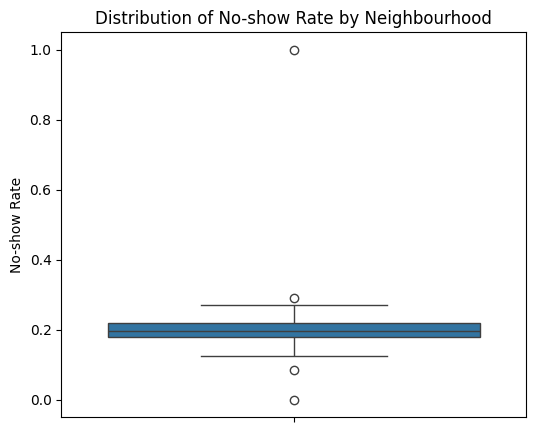

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 지역별 No-show 비율 확인 >> 1. box plot으로 이상치 확인, No-show 비율 분포 범위 확인
region_stats = df.groupby("Neighbourhood")["No_show"].mean()

plt.figure(figsize=(6,5))
sns.boxplot(y=region_stats)

plt.title("Distribution of No-show Rate by Neighbourhood")
plt.ylabel("No-show Rate")

plt.show()

In [16]:
#지역별 No-show 비율 확인 >> 2. 표본 수가 적은 지역 제거 (분석의 신뢰성을 위해)

region_stats = df.groupby('Neighbourhood').agg(
    patient_count=('Neighbourhood','count'),
    noshow_rate=('No_show','mean')
).sort_values('noshow_rate', ascending=False)

region_stats.head(20)

,patient_count,noshow_rate
Neighbourhood,,
ILHAS OCEÂNICAS DE TRINDADE,2,1.000000
SANTOS DUMONT,1249,0.291433
SANTA CECÍLIA,443,0.270880
SANTA CLARA,496,0.266129
ITARARÉ,3412,0.263189
JESUS DE NAZARETH,2719,0.248621
ILHA DO PRÍNCIPE,2222,0.236274
CARATOÍRA,2489,0.235436
ANDORINHAS,2195,0.231891


In [17]:
# 지역별 환자 수 계산
region_count = df.groupby("Neighbourhood").size()
# 최소 환자 수 기준 설정
min_patient = 100
# 환자 수가 충분한 지역만 선택
valid_regions = region_count[region_count >= min_patient].index
# 데이터에서 해당 지역만 남기기
df = df[df["Neighbourhood"].isin(valid_regions)]
# 지역별 노쇼 평균 계산
region_noshow_rate = df.groupby("Neighbourhood")["No_show"].mean()
# 새로운 feature 생성
df["region_noshow_rate"] = df["Neighbourhood"].map(region_noshow_rate)
# 결과 확인
df[["Neighbourhood", "region_noshow_rate"]].head()

,Neighbourhood,region_noshow_rate
0,JARDIM DA PENHA,0.162815
1,JARDIM DA PENHA,0.162815
2,MATA DA PRAIA,0.171340
4,JARDIM DA PENHA,0.162815
5,REPÚBLICA,0.171779


In [18]:
df

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score,region_noshow_rate
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,4,4,1,0.162815
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,4,4,0,0.162815
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,4,4,0,0.171340
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,4,4,2,0.162815
5,F,76,REPÚBLICA,0,1,0,0,0,0,2,0,2,4,1,0.171779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106982,F,56,MARIA ORTIZ,0,0,0,0,0,1,35,0,1,1,0,0.214632
106983,F,51,MARIA ORTIZ,0,0,0,0,0,1,35,0,1,1,0,0.214632
106984,F,21,MARIA ORTIZ,0,0,0,0,0,1,41,0,2,1,0,0.214632
106985,F,38,MARIA ORTIZ,0,0,0,0,0,1,41,0,2,1,0,0.214632


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106763 entries, 0 to 106986
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Gender               106763 non-null  object 
 1   Age                  106763 non-null  int64  
 2   Neighbourhood        106763 non-null  object 
 3   Scholarship          106763 non-null  int64  
 4   Hipertension         106763 non-null  int64  
 5   Diabetes             106763 non-null  int64  
 6   Alcoholism           106763 non-null  int64  
 7   Handcap              106763 non-null  int64  
 8   SMS_received         106763 non-null  int64  
 9   Date.diff            106763 non-null  int64  
 10  No_show              106763 non-null  int64  
 11  scheduled_weekday    106763 non-null  int32  
 12  appointment_weekday  106763 non-null  int32  
 13  chronic_score        106763 non-null  int64  
 14  region_noshow_rate   106763 non-null  float64
dtypes: float64(1), int32(2

## 2. EDA

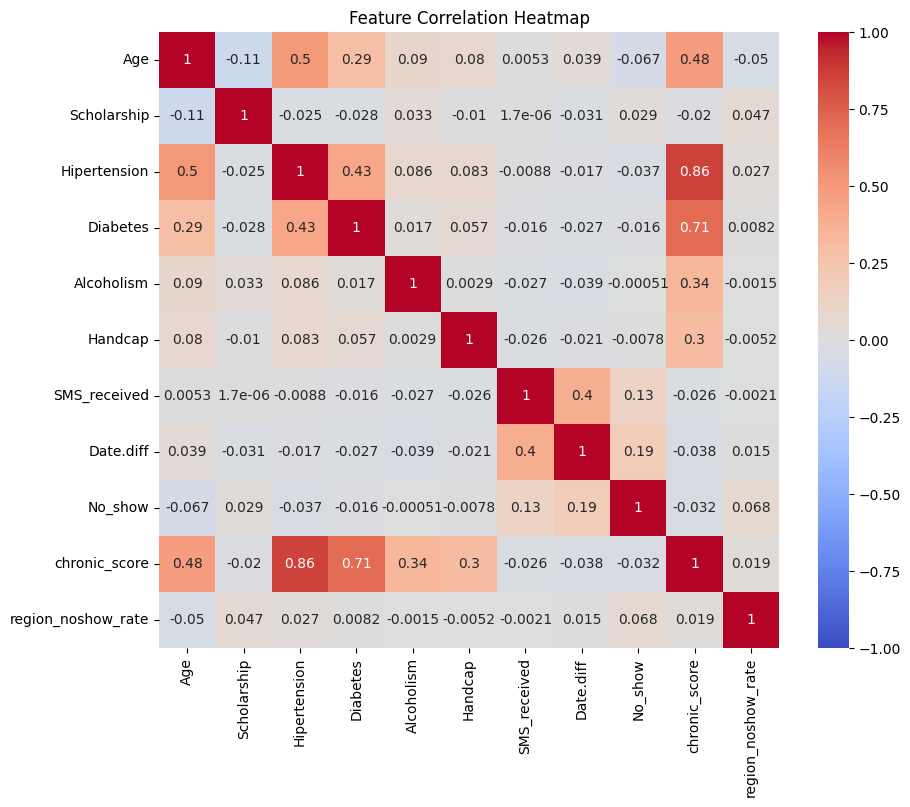

In [20]:
#숫자형 변수들 상관관계 확인

# 숫자형 컬럼만 선택
numeric_cols = df.select_dtypes(include=['int64','float64'])

# 상관계수 계산
corr = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Feature Correlation Heatmap")
plt.show()

* 질병 ↔ chronic_score간 상관관계 존재.

  → 이는 chronic_score만으로도 질병에서 얻을 수 있는 정보를 찾을 수 있기 때문에 질병에 관한 칼럼은 삭제해도 무관

In [21]:
df = df.drop(columns=['Hipertension', 'Diabetes', 'Alcoholism', 'Handcap'])

<Axes: xlabel='No_show', ylabel='Date.diff'>

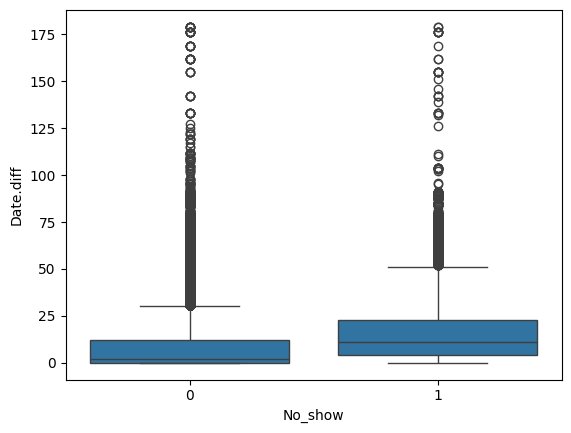

In [22]:
sns.boxplot(x="No_show", y="Date.diff", data=df)

* No_show가 1일 때 Date.diff의 값이 크고, 중앙값 역시 큼
  → 예약 대기시간이 길수록 No-show 확률이 증가


/tmp/ipykernel_821/3248944853.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  date_noshow = df.groupby("Date_diff_group")["No_show"].mean().reset_index()


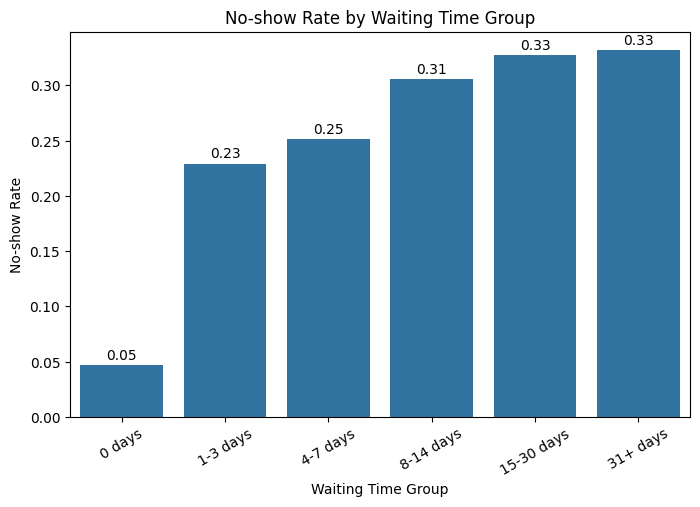

In [23]:
# Date.diff 구간 정의
bins = [-1, 0, 3, 7, 14, 30, df["Date.diff"].max()]
labels = ["0 days", "1-3 days", "4-7 days", "8-14 days", "15-30 days", "31+ days"]

df["Date_diff_group"] = pd.cut(df["Date.diff"], bins=bins, labels=labels)

# 구간별 No-show 비율 계산
date_noshow = df.groupby("Date_diff_group")["No_show"].mean().reset_index()

# 시각화
plt.figure(figsize=(8,5))
ax = sns.barplot(x="Date_diff_group", y="No_show", data=date_noshow)

for i, v in enumerate(date_noshow["No_show"]):
    ax.text(i, v + 0.005, f"{v:.2f}", ha="center")

plt.title("No-show Rate by Waiting Time Group")
plt.xlabel("Waiting Time Group")
plt.ylabel("No-show Rate")
plt.xticks(rotation=30)

plt.show()

In [24]:
date_count = df["Date_diff_group"].value_counts().sort_index()
print(date_count)

Date_diff_group
0 days        37090
1-3 days      14255
4-7 days      17115
8-14 days     11614
15-30 days    16696
31+ days       9993
Name: count, dtype: int64


예약 후 진료일까지의 대기 기간을 구간화하여 No-show 비율을 분석한 결과, 대기 기간이 증가할수록 No-show 비율이 증가하는 경향이 나타났다. 특히 당일 예약의 경우 No-show 비율이 약 5% 수준으로 매우 낮았으나, 대기 기간이 30일 이상인 경우 약 33%까지 증가하였다. 이는 예약 후 진료일까지의 시간이 길어질수록 환자의 방문 의지가 감소하거나 일정 변경 가능성이 증가하기 때문으로 해석할 수 있다.

<Axes: xlabel='SMS_received', ylabel='No_show'>

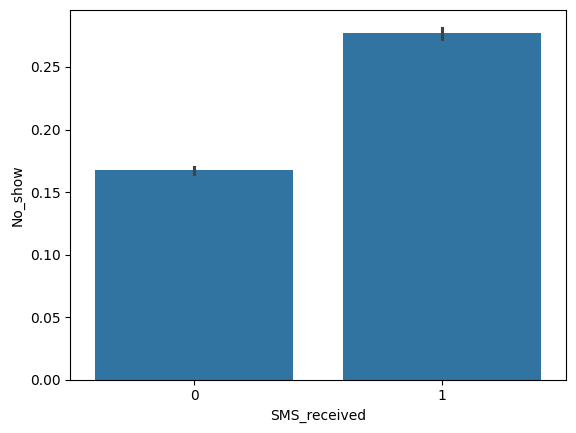

In [25]:
sns.barplot(x="SMS_received", y="No_show", data=df)

*  SMS를 수신한 환자의 No-show 비율이 높음 -> 젊은 연령층의 No-show 비율에 의해 편향된 것일 수도 있기 때문에 그룹별 확인이 다시 필요

In [26]:
#나이대별로 그룹 분류

import pandas as pd

bins = [0, 12, 19, 39, 59, 120]
labels = ["Child (0-12)", "Teen (13-19)", "Young Adult (20-39)", "Middle Age (40-59)", "Senior (60+)"]

df["Age_group"] = pd.cut(df["Age"], bins=bins, labels=labels)

/tmp/ipykernel_821/3327510789.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sms_rate = df.groupby("Age_group")["SMS_received"].mean().reset_index()


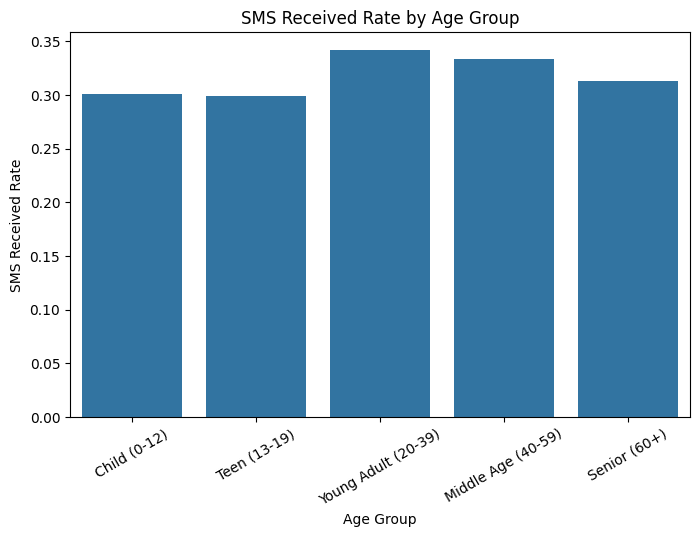

In [27]:
#나이대별 SMS 수신 비율

sms_rate = df.groupby("Age_group")["SMS_received"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Age_group", y="SMS_received", data=sms_rate)

plt.title("SMS Received Rate by Age Group")
plt.ylabel("SMS Received Rate")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

나이대별 SMS 수신 비율은 비슷함

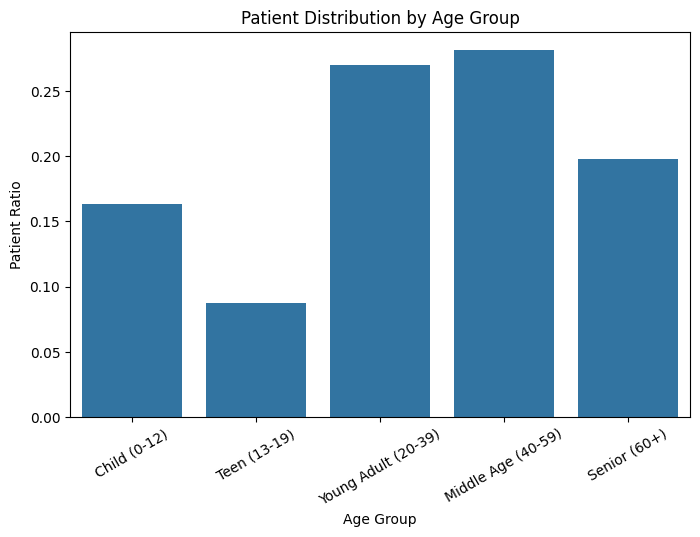

In [28]:
#나이대별 환자 비율

age_distribution = df["Age_group"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=age_distribution.index, y=age_distribution.values)

plt.title("Patient Distribution by Age Group")
plt.ylabel("Patient Ratio")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_821/629285766.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chronic_by_age = df.groupby("Age_group")["chronic_score"].mean().reset_index()


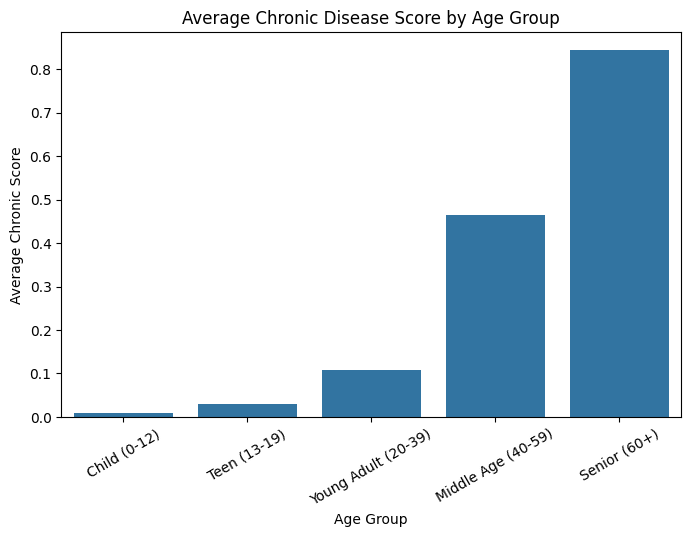

In [29]:
#나이대별 질병 개수 평균

chronic_by_age = df.groupby("Age_group")["chronic_score"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Age_group", y="chronic_score", data=chronic_by_age)

plt.title("Average Chronic Disease Score by Age Group")
plt.ylabel("Average Chronic Score")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

/tmp/ipykernel_821/1255441956.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  noshow_age = df.groupby("Age_group")["No_show"].mean().reset_index()


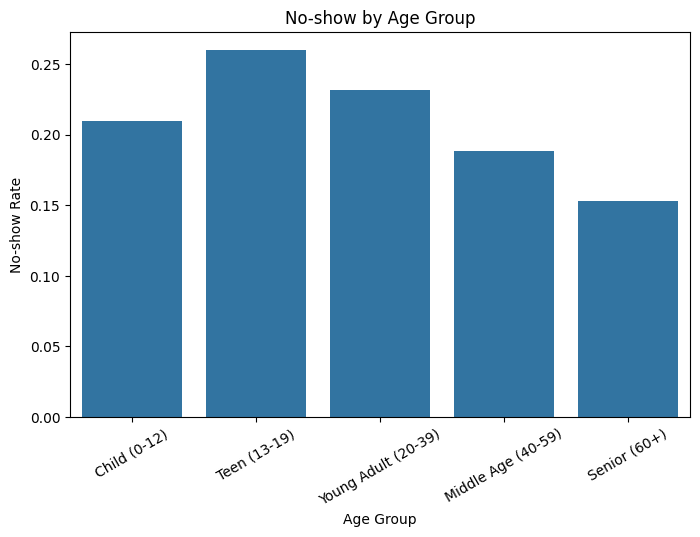

In [30]:
#나이대별 노쇼 여부
noshow_age = df.groupby("Age_group")["No_show"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Age_group", y="No_show", data=noshow_age)

plt.title("No-show by Age Group")
plt.ylabel("No-show Rate")
plt.xlabel("Age Group")

plt.xticks(rotation=30)
plt.show()

child를 제외한 나이대에서 나이가 어릴수록 No-show 비율이 높음

<Axes: xlabel='No_show', ylabel='Age'>

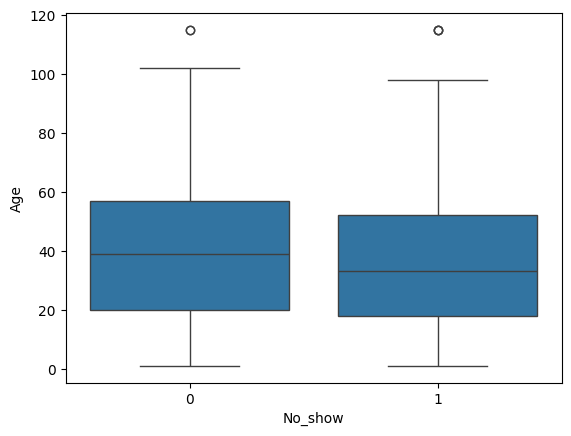

In [31]:
sns.boxplot(x="No_show", y="Age", data=df)

* No-show 환자의 나이의 중앙값이 조금 더 낮음, 그러나 차이가 크지 않아서 영향이 크진 않음

<Axes: xlabel='chronic_score', ylabel='No_show'>

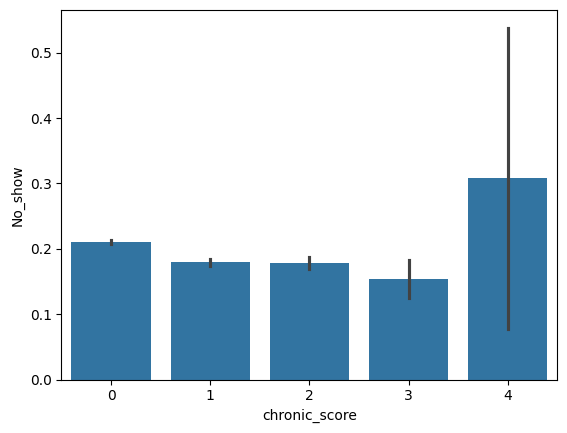

In [32]:
sns.barplot(x="chronic_score", y="No_show", data=df)

* 질병이 1~3개는 No-show율이 낮아지는데, 4에서 갑자기 튐 -> 표본이 적어서 튈 수 있으니 확인 필요

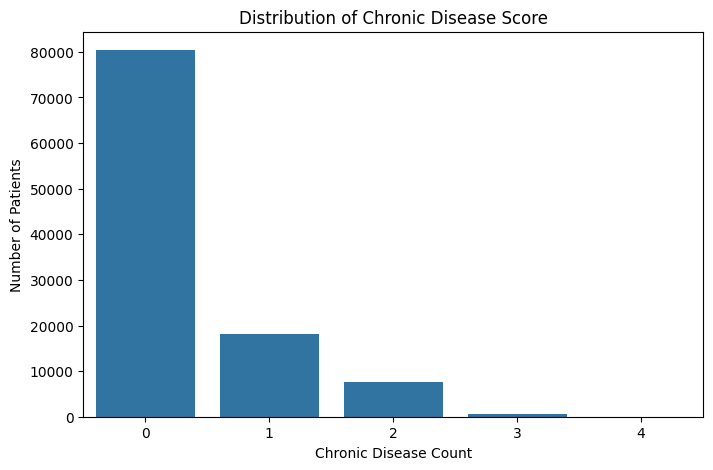

In [33]:
#질병 개수 분포 -> 4개를 모두 가진 만성질환의 환자가 적어 데이터가 튄 것
chronic_count = df["chronic_score"].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=chronic_count.index, y=chronic_count.values)

plt.title("Distribution of Chronic Disease Score")
plt.ylabel("Number of Patients")
plt.xlabel("Chronic Disease Count")

plt.show()

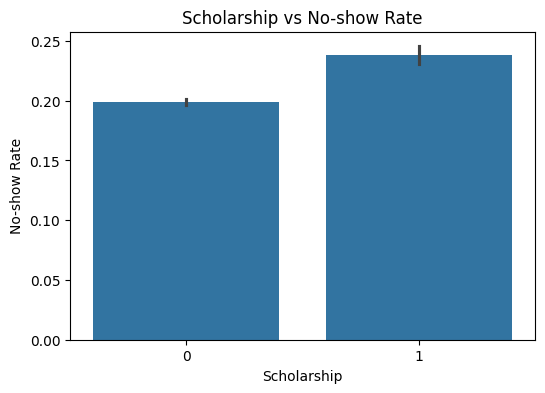

In [34]:
plt.figure(figsize=(6,4))

sns.barplot(x="Scholarship", y="No_show", data=df)

plt.title("Scholarship vs No-show Rate")
plt.ylabel("No-show Rate")
plt.xlabel("Scholarship")

plt.show()

* 지원 대상 환자 no=show가 높음. 그러나 0과 차이가 크지 않음

## EDA 중간 결과 정리

① 연령대별 환자 분포 : 병원을 이용하는 주요 환자층은 중년층

② 연령대별 SMS 수신 비율 : 모든 연령대에서 SMS 수신율은 약 30%, 병원은 특정 연령층에 집중적으로 SMS를 보낸다기보다 전체 환자에게 균등하게 알림을 발송

③ 연령대별 만성질환 개수 : 연령이 증가할수록 만성질환이 증가함 (heatmap에서의 상관관계에서 만성질환 관련 변수 간 비교적 높은 상관관계를 보임 -> 근데 이건 꼭 필요할지 모르겠)

④ 연령대별 No-show 비율 : 젊을수록 No-show 비율이 높음 -> 일정 변경, 건강의 필요성 차이일 가능성 있음

⑤ 대기시간과 No-show : 예약일부터 진료일까지의 대기기간이 길어질수록 No-show 비율이 증가 (당일 예약 5% -> 30일 이상 33%)

⑥ 핵심 인사이트 : 대기시간이 길수록 No-show 증가 / 젊은 환자일수록 No-show 많음 / 고령층은 만성질환이 많지만 방문률 높음 / SMS 발송은 연령에 큰 차이가 없음

--> 제안 가능한 정책 : 대기기간 긴 환자에게 추가 알림 / 젊은 환자에게 추가 리마인드 / 예약 재확인 시스템



In [35]:
df.head()

,Gender,Age,Neighbourhood,Scholarship,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score,region_noshow_rate,Date_diff_group,Age_group
0,F,62,JARDIM DA PENHA,0,0,0,0,4,4,1,0.162815,0 days,Senior (60+)
1,M,56,JARDIM DA PENHA,0,0,0,0,4,4,0,0.162815,0 days,Middle Age (40-59)
2,F,62,MATA DA PRAIA,0,0,0,0,4,4,0,0.171340,0 days,Senior (60+)
4,F,56,JARDIM DA PENHA,0,0,0,0,4,4,2,0.162815,0 days,Middle Age (40-59)
5,F,76,REPÚBLICA,0,0,2,0,2,4,1,0.171779,1-3 days,Senior (60+)


## 3. Feature Engineering

1. Wating Time Category: wating time과 no-show 비율의 강한 비례적 상관관계
2. Chronic Disease Count : 만성 질환이 많으면 병원 방문 확률이 높아질 것이라는 가설 하에 대입
3. 2번 내용에 더해 질병 유무 (Has Chronic Disease) (모델에 학습을 돕기 위해 Binary feature 추가)
4. Age Group Encoding : 어릴수록 no-show 비율이 높기 때문에 대입
5. High Risk Wating Flag : 14일 이후 no-show가 급증하는 패턴을 반영하여 대기시간이 길어지는 경우 따로 Flag
6. SMS + Long Wait Interaction : 대기시간이 긴 환자에게 SMS 수신이 효과가 있는지 모델이 학습

In [36]:
#Wating Time Category : EDA과정에서 한번 진행했지만 헷갈리지 않기 위해 다시 진행, 카테고리화 후 모델에 적용하기 위해 숫자로 변환

bins = [-1, 0, 3, 7, 14, 30, df["Date.diff"].max()]
labels = ["0", "1-3", "4-7", "8-14", "15-30", "31+"]

df["waiting_time_group"] = pd.cut(df["Date.diff"], bins=bins, labels=labels)

df["waiting_time_group"] = df["waiting_time_group"].cat.codes

In [37]:
#Has Chronic Disease (binary)

df["has_chronic_disease"] = (df["chronic_score"] > 0).astype(int)

In [38]:
#Age Group Encoding

age_map = {
    "Child (0-12)":0,
    "Teen (13-19)":1,
    "Young Adult (20-39)":2,
    "Middle Age (40-59)":3,
    "Senior (60+)":4
}

df["age_group_encoded"] = df["Age_group"].map(age_map)

In [39]:
#SMS + Long Wait Interaction

df["long_wait"] = (df["Date.diff"] >= 14).astype(int)
df["sms_long_wait"] = df["SMS_received"] * df["long_wait"]

In [40]:
df.head()

,Gender,Age,Neighbourhood,Scholarship,SMS_received,Date.diff,No_show,scheduled_weekday,appointment_weekday,chronic_score,region_noshow_rate,Date_diff_group,Age_group,waiting_time_group,has_chronic_disease,age_group_encoded,long_wait,sms_long_wait
0,F,62,JARDIM DA PENHA,0,0,0,0,4,4,1,0.162815,0 days,Senior (60+),0,1,4,0,0
1,M,56,JARDIM DA PENHA,0,0,0,0,4,4,0,0.162815,0 days,Middle Age (40-59),0,0,3,0,0
2,F,62,MATA DA PRAIA,0,0,0,0,4,4,0,0.171340,0 days,Senior (60+),0,0,4,0,0
4,F,56,JARDIM DA PENHA,0,0,0,0,4,4,2,0.162815,0 days,Middle Age (40-59),0,1,3,0,0
5,F,76,REPÚBLICA,0,0,2,0,2,4,1,0.171779,1-3 days,Senior (60+),1,1,4,0,0


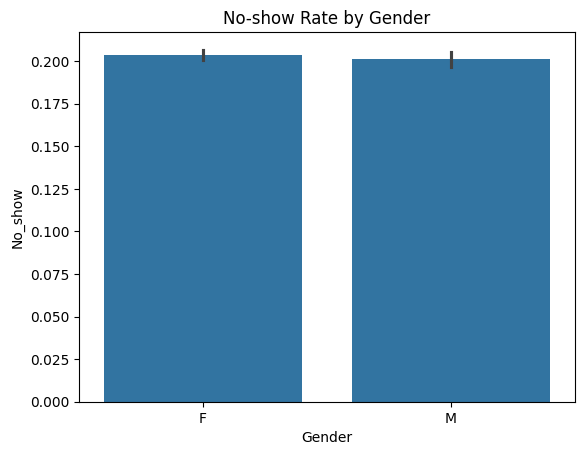

In [41]:
#성별 넣기 전에 성별 비율 및 성병 노쇼 비율 확인
#-> 차이가 거의 없음, 그러나 변수 하나 추가한다고 비용이 많이 드는 것도 아니고, 다른 변수와의 상관관계가 있을 수 있으니까 일단 Feature에 추가
sns.barplot(x="Gender", y="No_show", data=df)

plt.title("No-show Rate by Gender")
plt.show()

In [42]:
df.groupby("Gender")["No_show"].mean()

,No_show
Gender,
F,0.203607
M,0.200951


In [43]:
df["gender_binary"] = df["Gender"].map({"F":0, "M":1})

## 3. Model

* 데이터 누수 발생을 막기 위해 rigion_no_show_rate를 test, train 데이터로 나누어 다시 계산 (데이터 덮어씌움)

이후 Random Forest, XGBoost 등 비선형 모델과 성능을 비교

In [44]:
from sklearn.model_selection import train_test_split

# feature와 target 분리
X = df.drop(columns=["No_show"])
y = df["No_show"]

# train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, #이거 왜 이 수치로 했는지 작성해야함!!!!!!!!!!!
    random_state=42,
    stratify=y #노쇼 비율 유지
)

In [45]:
#train 기준 region no-show rate 계산
# train 데이터에 target 다시 붙이기

train_df = X_train.copy()
train_df["No_show"] = y_train

# region별 no-show 평균 계산 (train 기준)
region_rate = train_df.groupby("Neighbourhood")["No_show"].mean()

In [46]:
X_train["region_noshow_rate"] = X_train["Neighbourhood"].map(region_rate)

In [47]:
X_test["region_noshow_rate"] = X_test["Neighbourhood"].map(region_rate)

In [48]:
global_rate = y_train.mean()

X_test["region_noshow_rate"].fillna(global_rate, inplace=True)

/tmp/ipykernel_821/2343809114.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["region_noshow_rate"].fillna(global_rate, inplace=True)


In [49]:
X_train = X_train.drop(columns=["Neighbourhood"])
X_test = X_test.drop(columns=["Neighbourhood"])

In [50]:
print(X_train.columns)

Index(['Gender', 'Age', 'Scholarship', 'SMS_received', 'Date.diff',
       'scheduled_weekday', 'appointment_weekday', 'chronic_score',
       'region_noshow_rate', 'Date_diff_group', 'Age_group',
       'waiting_time_group', 'has_chronic_disease', 'age_group_encoded',
       'long_wait', 'sms_long_wait', 'gender_binary'],
      dtype='object')


1) Logistic Regression

Logistic Regression은 이진 분류 문제에서 가장 기본적인 baseline 모델로,
각 변수의 영향 방향을 해석하기 쉽다는 장점이 있음

In [51]:
# Logistic Regression Baseline Model

# 필요한 라이브러리 불러오기
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 1) 최종 feature 선택 -> train/test에 남아 있는 불필요한 컬럼(Gender, Age_group 등)을 제거하기 위함
features = [
    "gender_binary",
    "Age",
    "Scholarship",
    "SMS_received",
    "Date.diff",
    "waiting_time_group",
    "chronic_score",
    "long_wait",
    "sms_long_wait",
    "region_noshow_rate"
]

X_train_model = X_train[features].copy()
X_test_model = X_test[features].copy()

# 2) 스케일링
# Logistic Regression은 거리/계수 기반 모델이라 변수들의 스케일 차이가 크면 학습이 왜곡될 수 있음, 따라서 StandardScaler로 평균 0, 표준편차 1 기준으로 맞춰줌.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model) # fit은 train에만 적용 -> test 정보를 미리 보면 data leakage가 생길 수 있음
X_test_scaled = scaler.transform(X_test_model)

# 3) Logistic Regression 모델 정의
log_model = LogisticRegression(
    max_iter=1000, # 기본값으로는 수렴이 안 될 수 있어서 반복 횟수를 늘림
    random_state=42, # 결과 재현성을 위해 고정
    class_weight="balanced" # No-show(1)가 약 20% 정도라 약간 불균형 데이터이므로 소수 클래스(No-show)를 너무 무시하지 않도록 가중치를 자동 보정
)

# 4) 모델 학습
log_model.fit(X_train_scaled, y_train)

# 5) 예측
y_pred = log_model.predict(X_test_scaled)

y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1] # predict_proba는 ROC-AUC 계산용, [:, 1]은 No_show=1일 확률

# 6) 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Logistic Regression Baseline ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Logistic Regression Baseline ===
Accuracy : 0.6338
Precision: 0.3198
Recall   : 0.7160
F1-score : 0.4421
ROC-AUC  : 0.7208

=== Confusion Matrix ===
[[10434  6591]
 [ 1229  3099]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.61      0.73     17025
           1       0.32      0.72      0.44      4328

    accuracy                           0.63     21353
   macro avg       0.61      0.66      0.58     21353
weighted avg       0.78      0.63      0.67     21353



In [52]:
# 7) 회귀계수 확인
# coef_ > 0 이면 No-show(1) 확률을 높이는 방향
# coef_ < 0 이면 No-show(1) 확률을 낮추는 방향

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print(coef_df)

              Feature  Coefficient
5  waiting_time_group     1.370478
9  region_noshow_rate     0.142869
2         Scholarship     0.060609
6       chronic_score     0.035498
0       gender_binary     0.011575
8       sms_long_wait    -0.048599
3        SMS_received    -0.086193
1                 Age    -0.198159
4           Date.diff    -0.291369
7           long_wait    -0.333859


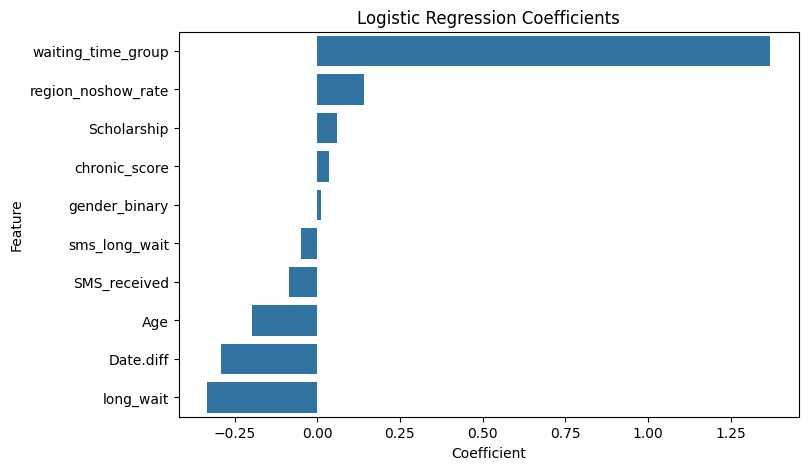

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

* multicollinearity 발생

'Date.diff', 'waiting_time_group', 'long_wait' 3개가 같은 정보를 가진 변수인데 계수가 뒤집히는 상황 발생(multicollinearity)

선형 관계 확인에 유리하도록 그룹화, 이분법으로 칼럼을 만들었으나 의미없는 것 같음 --> 삭제해도 될 것 같은데

선형관계의 Logistic Regression이 적합하지 않은 비선형 관계가 있을 수 있음
==> Random Forest

** 데이터 정보가 가장 많은 Date.diff만 Feature에 남겨두고 Logistic Regression다시 실행

** 이후 Random Forest 결과와 비교

In [54]:
# -------------------------------
# 1. 최종 feature 다시 선택
# -------------------------------
# Date.diff만 남기고
# waiting_time_group, long_wait는 제거
features = [
    "gender_binary",
    "Age",
    "Scholarship",
    "SMS_received",
    "Date.diff",
    "chronic_score",
    "sms_long_wait",
    "region_noshow_rate"
]

X_train_model = X_train[features].copy()
X_test_model = X_test[features].copy()

# -------------------------------
# 2. Logistic Regression용 스케일링
# -------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

# -------------------------------
# 3. Logistic Regression 다시 학습
# -------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)
import pandas as pd

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

# 예측
y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

# 성능 평가
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Logistic Regression (Refined Features) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 계수 확인
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\n=== Logistic Regression Coefficients ===")
print(coef_df)

=== Logistic Regression (Refined Features) ===
Accuracy : 0.6551
Precision: 0.3167
Recall   : 0.6058
F1-score : 0.4159
ROC-AUC  : 0.6791

=== Confusion Matrix ===
[[11367  5658]
 [ 1706  2622]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.67      0.76     17025
           1       0.32      0.61      0.42      4328

    accuracy                           0.66     21353
   macro avg       0.59      0.64      0.59     21353
weighted avg       0.76      0.66      0.69     21353


=== Logistic Regression Coefficients ===
              Feature  Coefficient
4           Date.diff     0.506880
3        SMS_received     0.260375
7  region_noshow_rate     0.162561
2         Scholarship     0.056549
5       chronic_score     0.025231
0       gender_binary    -0.002644
6       sms_long_wait    -0.183970
1                 Age    -0.186570


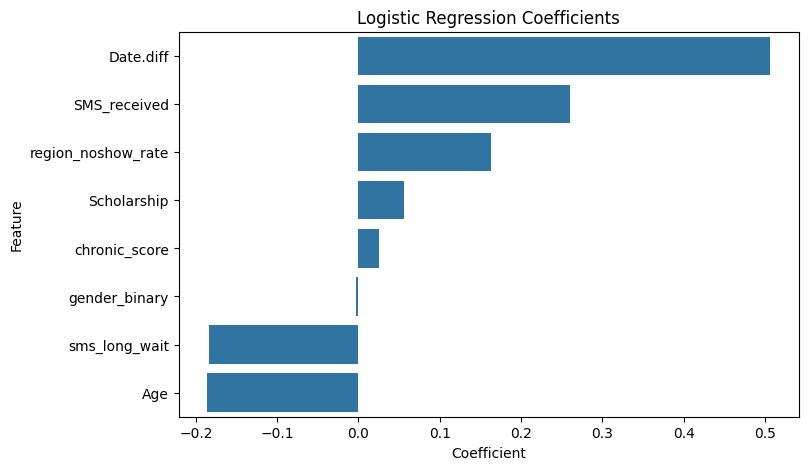

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=coef_df, x="Coefficient", y="Feature")

plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

정확도가 이전보다 올라간 모습 (이전과 많은 차이는 없음)

그러나 이전에는 중복되는 정보가 있었기 때문에 노쇼 패턴을 과하게 잡았을 가능성 있기 때문에 훨씬 깔끔


* 계수 해석

1. 가장 영향이 큰 변수 : Date.diff, 대기시간이 길수록 노쇼 확률 증가

2. SMS_reeived : SMS를 받을수록 No-show 비율이 높다 --> SMS 수신자 자체가 노쇼 위험군이어서 받았을 수 있응

3. region_noshow_rate : 노쇼가 많은 지역에서 노쇼 확률이 높다는 건 내 Feature가 잘 작동한다는 증거

4. Age : 나이가 많을수록 노쇼 감소

5. sms_long_wait : 긴 대시시간 환자에게 SMS가 가면 노쇼 확률이 감소한다

이걸로 no show문제의 해결 방법을 어디서 찾을 수 있지 무슨 방법이 있지

### 2. Ramdom Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# Random Forest (개선 버전)
# -----------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",   # No-show(1)가 적은 불균형 데이터라 가중치 보정
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_model, y_train)

# 예측 확률
y_pred_proba = rf_model.predict_proba(X_test_model)[:, 1]

# -----------------------
# 기본 threshold = 0.5 결과
# -----------------------
y_pred_default = (y_pred_proba >= 0.5).astype(int)

print("=== Random Forest (threshold=0.5) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_default):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_default):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_default))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_default))

=== Random Forest (threshold=0.5) ===
Accuracy : 0.6949
Precision: 0.3467
Recall   : 0.5716
F1-score : 0.4316
ROC-AUC  : 0.7295

=== Confusion Matrix ===
[[12364  4661]
 [ 1854  2474]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.73      0.79     17025
           1       0.35      0.57      0.43      4328

    accuracy                           0.69     21353
   macro avg       0.61      0.65      0.61     21353
weighted avg       0.76      0.69      0.72     21353



Logistic에 비해 정확도가 높게 나옴

              Feature  Importance
4           Date.diff    0.431174
1                 Age    0.267363
7  region_noshow_rate    0.231006
3        SMS_received    0.023311
5       chronic_score    0.017221
0       gender_binary    0.012660
6       sms_long_wait    0.010847
2         Scholarship    0.006416


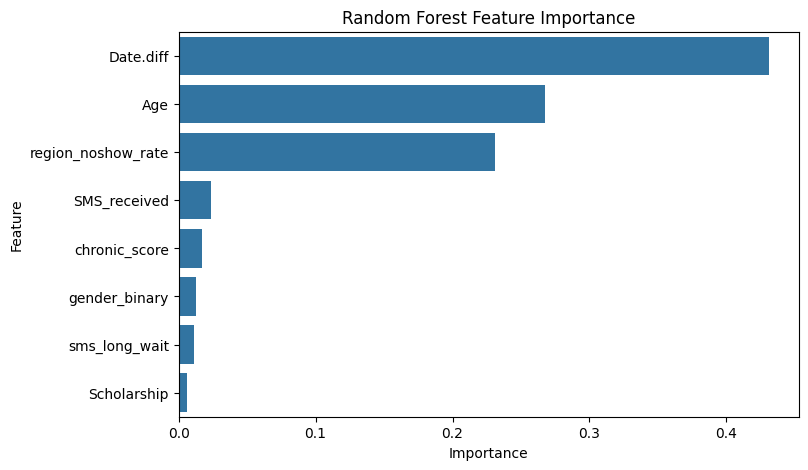

In [59]:
# Feature Importance 분석

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x="Importance", y="Feature")

plt.title("Random Forest Feature Importance")
plt.show()

## 5. 모델 결과 기반 노쇼 해결 전략

강한 결과를 보인 부분 : Date.diff, Age, region_noshow_rate

1. 대기시간 관리

  -> EDA 과정 당시의 그래프를 통해 Date.diff > 14일에서 노쇼 비율이 높음 -> 해당 환자에게 추가 SMS 발송 or 예약 재확인

2. 젊은 환자들 리마인드

  -> EDA 과정 당시의 그래프를 통해 Age < 40 인 환자에게 당일 리마인드 메시지


3. 노쇼 높은 지역 관리

  -> region_noshow_rate 높은 지역에게 예약 확인 문자 or 전화


위와 같은 방법으로 no show 문제를 해결할 수 있다

In [62]:
risk_df = X_test_model.copy()
risk_df["prob"] = y_pred_proba
risk_df = risk_df.sort_values("prob", ascending=False)

risk_df.head(10)

,gender_binary,Age,Scholarship,SMS_received,Date.diff,chronic_score,sms_long_wait,region_noshow_rate,prob
68629,1,9,0,0,0,1,0,0.188300,0.931020
51329,1,9,1,0,0,0,0,0.214670,0.920296
68604,1,9,1,0,0,0,0,0.214670,0.920296
51523,1,9,1,0,0,0,0,0.214670,0.920296
51510,1,9,1,0,0,0,0,0.214670,0.920296
12937,1,5,0,0,31,0,0,0.191431,0.907637
10811,1,32,0,0,60,0,0,0.207181,0.891421
468,0,19,0,1,11,0,0,0.261091,0.890507
44773,0,19,0,1,68,0,1,0.249065,0.890347
47793,0,7,0,0,8,0,0,0.267990,0.883350
